In [1]:
import pandas as pd

path = r"C:\Users\thebe\OneDrive\Desktop\mexico-inflation-2018-2025\conjunto_de_datos_inpc_mensual.csv"

df = pd.read_csv(path, encoding="latin-1")
df.head()

,COBERTURA,PERIODICIDAD,FECHA,CONCEPTO,VALOR,UNIDAD_MEDIDA,ESTATUS
0,Nacional,Mensual,2021-02-01,Ãndice nacional de precios al consumidor (men...,110.907,Ãndice,Cifras definitivas
1,Nacional,Mensual,2021-02-01,Ãndice nacional de precios al consumidor (men...,110.061,Ãndice,Cifras definitivas
2,Nacional,Mensual,2021-02-01,Ãndice nacional de precios al consumidor (men...,112.216,Ãndice,Cifras definitivas
3,Nacional,Mensual,2021-02-01,Ãndice nacional de precios al consumidor (men...,107.734,Ãndice,Cifras definitivas
4,Nacional,Mensual,2021-02-01,Ãndice nacional de precios al consumidor (men...,113.524,Ãndice,Cifras definitivas


In [2]:
df.columns

Index(['COBERTURA', 'PERIODICIDAD', 'FECHA', 'CONCEPTO', 'VALOR',
       'UNIDAD_MEDIDA', 'ESTATUS'],
      dtype='object')

In [3]:
df["CONCEPTO"].drop_duplicates().tolist()[:10]

['Ã\x8dndice nacional de precios al consumidor (mensual), Resumen, SubÃ\xadndices subyacente y complementarios, Precios al Consumidor (INPC)',
 'Ã\x8dndice nacional de precios al consumidor (mensual), Resumen, SubÃ\xadndices subyacente y complementarios, Subyacente',
 'Ã\x8dndice nacional de precios al consumidor (mensual), Resumen, SubÃ\xadndices subyacente y complementarios, Subyacente, MercancÃ\xadas',
 'Ã\x8dndice nacional de precios al consumidor (mensual), Resumen, SubÃ\xadndices subyacente y complementarios, Subyacente, Servicios',
 'Ã\x8dndice nacional de precios al consumidor (mensual), Resumen, SubÃ\xadndices subyacente y complementarios, No subyacente',
 'Ã\x8dndice nacional de precios al consumidor (mensual), Resumen, SubÃ\xadndices subyacente y complementarios, No subyacente, Agropecuarios',
 'Ã\x8dndice nacional de precios al consumidor (mensual), Resumen, SubÃ\xadndices subyacente y complementarios, No subyacente, EnergÃ©ticos y tarifas autorizadas por el gobierno']

In [4]:
path = r"C:\Users\thebe\OneDrive\Desktop\mexico-inflation-2018-2025\conjunto_de_datos_inpc_mensual.csv"

df = pd.read_csv(path, encoding="utf-8-sig")
df.head()

,COBERTURA,PERIODICIDAD,FECHA,CONCEPTO,VALOR,UNIDAD_MEDIDA,ESTATUS
0,Nacional,Mensual,2021-02-01,Índice nacional de precios al consumidor (mens...,110.907,Índice,Cifras definitivas
1,Nacional,Mensual,2021-02-01,Índice nacional de precios al consumidor (mens...,110.061,Índice,Cifras definitivas
2,Nacional,Mensual,2021-02-01,Índice nacional de precios al consumidor (mens...,112.216,Índice,Cifras definitivas
3,Nacional,Mensual,2021-02-01,Índice nacional de precios al consumidor (mens...,107.734,Índice,Cifras definitivas
4,Nacional,Mensual,2021-02-01,Índice nacional de precios al consumidor (mens...,113.524,Índice,Cifras definitivas


In [5]:
df["CONCEPTO"].drop_duplicates().tolist()[:10]

['Índice nacional de precios al consumidor (mensual), Resumen, Subíndices subyacente y complementarios, Precios al Consumidor (INPC)',
 'Índice nacional de precios al consumidor (mensual), Resumen, Subíndices subyacente y complementarios, Subyacente',
 'Índice nacional de precios al consumidor (mensual), Resumen, Subíndices subyacente y complementarios, Subyacente, Mercancías',
 'Índice nacional de precios al consumidor (mensual), Resumen, Subíndices subyacente y complementarios, Subyacente, Servicios',
 'Índice nacional de precios al consumidor (mensual), Resumen, Subíndices subyacente y complementarios, No subyacente',
 'Índice nacional de precios al consumidor (mensual), Resumen, Subíndices subyacente y complementarios, No subyacente, Agropecuarios',
 'Índice nacional de precios al consumidor (mensual), Resumen, Subíndices subyacente y complementarios, No subyacente, Energéticos y tarifas autorizadas por el gobierno']

In [6]:
target = "Índice nacional de precios al consumidor (mensual), Resumen, Subíndices subyacente y complementarios, Precios al Consumidor (INPC)"

cpi = df[df["CONCEPTO"] == target].copy()
cpi[["FECHA", "VALOR"]].head()

,FECHA,VALOR
0,2021-02-01,110.907
7,2021-03-01,111.824
14,2021-04-01,112.190
21,2021-05-01,112.419
28,2021-06-01,113.018


In [7]:
cpi = cpi[["FECHA", "VALOR"]].copy()

cpi["FECHA"] = pd.to_datetime(cpi["FECHA"])
cpi["VALOR"] = pd.to_numeric(cpi["VALOR"], errors="coerce")

cpi = cpi.sort_values("FECHA").reset_index(drop=True)

cpi.head(), cpi.tail(), cpi.shape

(       FECHA      VALOR
 0 2003-01-01  53.525441
 1 2003-02-01  53.674122
 2 2003-03-01  54.012930
 3 2003-04-01  54.105144
 4 2003-05-01  53.930560,
          FECHA    VALOR
 254 2024-03-01  134.065
 255 2024-04-01  134.336
 256 2024-05-01  134.087
 257 2024-06-01  134.594
 258 2024-07-01  136.003,
 (259, 2))

In [8]:
cpi["FECHA"].min(), cpi["FECHA"].max()

(Timestamp('2003-01-01 00:00:00'), Timestamp('2024-07-01 00:00:00'))

In [9]:
cpi = cpi[(cpi["FECHA"] >= "2018-01-01") & (cpi["FECHA"] <= "2024-12-31")].copy()
cpi = cpi.reset_index(drop=True)

cpi = cpi.rename(columns={"FECHA": "date", "VALOR": "cpi"})

cpi["inflation_mom"] = cpi["cpi"].pct_change(1) * 100
cpi["inflation_yoy"] = cpi["cpi"].pct_change(12) * 100

cpi.head(15), cpi.tail(15), cpi.shape

(         date         cpi  inflation_mom  inflation_yoy
 0  2018-01-01   98.795000            NaN            NaN
 1  2018-02-01   99.171374       0.380965            NaN
 2  2018-03-01   99.492157       0.323463            NaN
 3  2018-04-01   99.154847      -0.339032            NaN
 4  2018-05-01   98.994080      -0.162137            NaN
 5  2018-06-01   99.376465       0.386270            NaN
 6  2018-07-01   99.909099       0.535976            NaN
 7  2018-08-01  100.492000       0.583431            NaN
 8  2018-09-01  100.917000       0.422919            NaN
 9  2018-10-01  101.440000       0.518248            NaN
 10 2018-11-01  102.303000       0.850749            NaN
 11 2018-12-01  103.020000       0.700859            NaN
 12 2019-01-01  103.108000       0.085420       4.365606
 13 2019-02-01  103.079000      -0.028126       3.940276
 14 2019-03-01  103.476000       0.385141       4.004178,
          date      cpi  inflation_mom  inflation_yoy
 64 2023-05-01  128.084      -0.2

In [10]:
output_path = r"C:\Users\thebe\OneDrive\Desktop\mexico-inflation-2018-2025\data_processed\inegi_cpi_clean.csv"
cpi.to_csv(output_path, index=False, encoding="utf-8-sig")

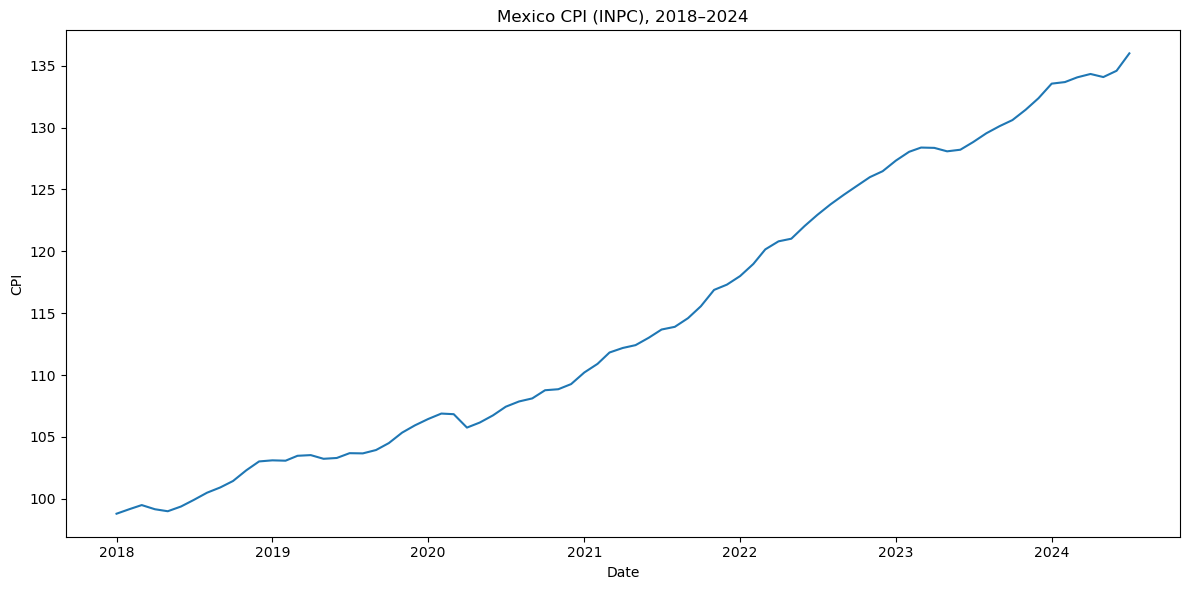

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(cpi["date"], cpi["cpi"])
plt.title("Mexico CPI (INPC), 2018–2024")
plt.xlabel("Date")
plt.ylabel("CPI")
plt.tight_layout()
plt.show()

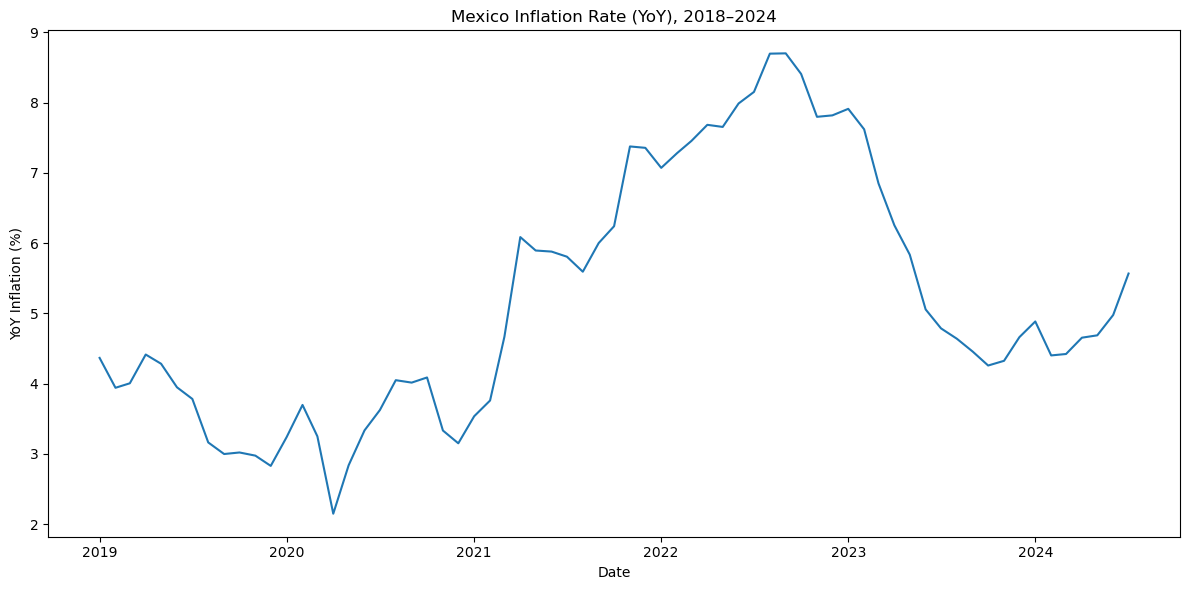

In [12]:
plt.figure(figsize=(12,6))
plt.plot(cpi["date"], cpi["inflation_yoy"])
plt.title("Mexico Inflation Rate (YoY), 2018–2024")
plt.xlabel("Date")
plt.ylabel("YoY Inflation (%)")
plt.tight_layout()
plt.show()

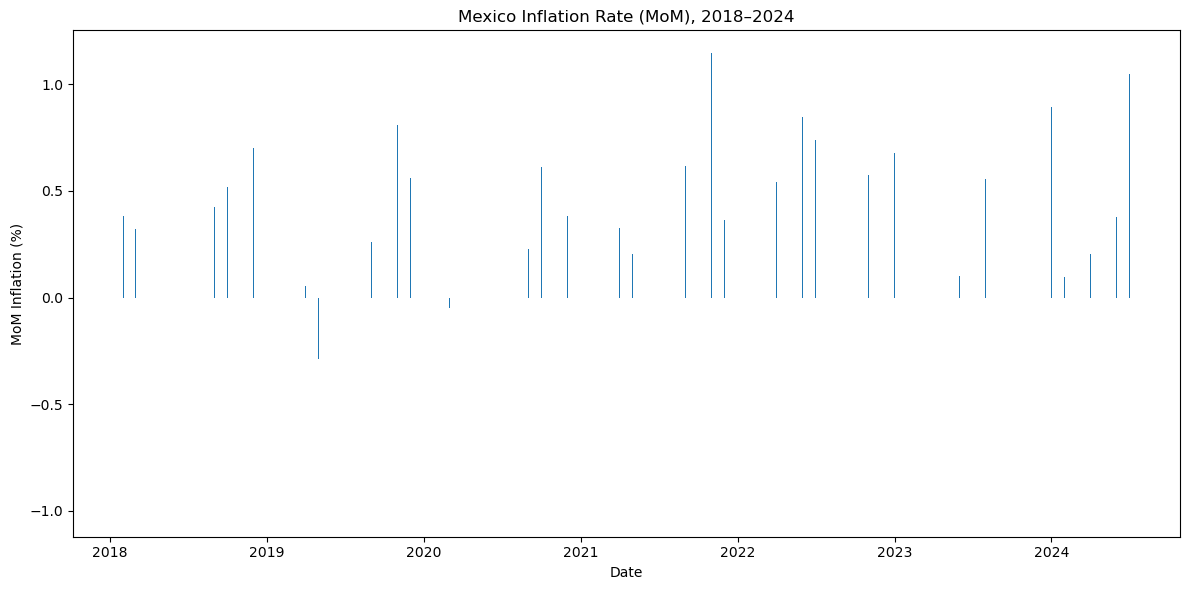

In [13]:
plt.figure(figsize=(12,6))
plt.bar(cpi["date"], cpi["inflation_mom"])
plt.title("Mexico Inflation Rate (MoM), 2018–2024")
plt.xlabel("Date")
plt.ylabel("MoM Inflation (%)")
plt.tight_layout()
plt.show()

In [14]:
latest = cpi.iloc[-1]
print("Latest date:", latest["date"].date())
print("Latest CPI:", round(latest["cpi"], 3))
print("Latest MoM inflation (%):", round(latest["inflation_mom"], 3))
print("Latest YoY inflation (%):", round(latest["inflation_yoy"], 3))

Latest date: 2024-07-01
Latest CPI: 136.003
Latest MoM inflation (%): 1.047
Latest YoY inflation (%): 5.566
